In [27]:
import matplotlib.pyplot as plt
import scienceplots
# plt.style.use('science')
plt.style.use(['science', 'nature', 'grid'])

from matplotlib.lines import Line2D

import string
import numpy as np
from scipy.interpolate import interp1d
import pandas as pd
import json

from LoadTSV import read_solution_file, interpolate_solution, sol_final

In [28]:
WIDTH = 6.0 
HEIGHT = 2.5 #5.0

plt.rcParams.update({
    "figure.figsize": (WIDTH, HEIGHT),
    "font.size": 10,           # Matches thesis 10pt
    "axes.labelsize": 10,
    "legend.fontsize": 8,      # Slightly smaller for legends
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1,
    "lines.markersize": 4,
    "savefig.bbox": 'tight',   # Ensures no labels are cut off
    "savefig.pad_inches": 0.05
})

labels = string.ascii_lowercase

In [29]:
colors = ['blue', 'orange', 'green', 'red', 'purple']

In [30]:
Moments = [4, 8]
closure_vec = ["Gram", "ExtGram"]
Kn = 1.0
source = "relaxation_source"
T_end = 25.0
base_tree_level = 10
polydeg = 1

# Initial condition parameters for the RH problem
Mach = np.array([1.4, 2.0])

rho_L = 1.0
rho_R = lambda Ma: (2*Ma**2) / (Ma**2 + 1)
v_L = lambda Ma: np.sqrt(3) * Ma
v_R = lambda Ma: np.sqrt(3) / 2 * (Ma**2 + 1) / Ma
theta_L = 1.0
theta_R = lambda Ma: (3*Ma**2 - 1) * (Ma**2 + 1) / (4 * Ma**2)

x_lower = -20.0
x_upper = 100.0

In [31]:
filename_moments = lambda M, closure, rho_L, rho_R, v_L, v_R, theta_L, theta_R: f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

In [32]:
# Reference solution
reference_path = [f'../out/Riemann1D/ReferenceSolution/RankineHugoniot_Ma{str(Ma).split(".")[0]}_{str(Ma).split(".")[1]}.json' for Ma in Mach]
ref_data = []
for file_path in reference_path:
    with open(file_path, 'r') as file:
        data = json.load(file)

        # Extract the data and store it in a dictionary
        data_Ma = {}
        for data_point in data['datasetColl']:
            x, y = [], []
            for i in range(len(data_point['data'])):
                x.append(data_point['data'][i]['value'][0])
                y.append(data_point['data'][i]['value'][1])
            data_Ma[data_point['name']] = (np.array(x), np.array(y))
        ref_data.append(data_Ma)

/tmp/ipykernel_21642/1533873398.py:53: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


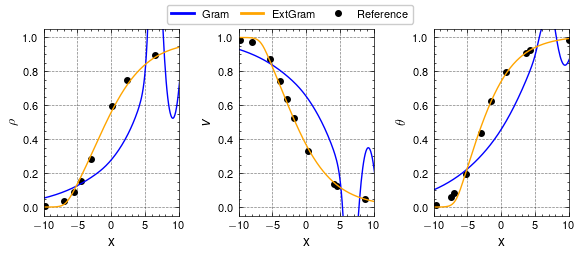

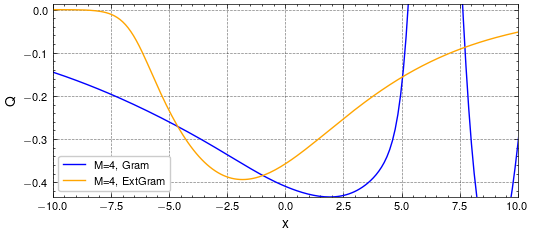

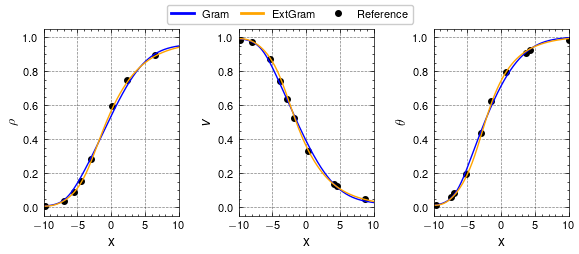

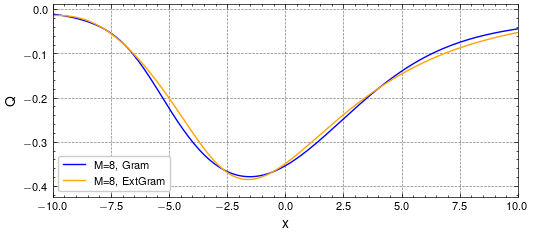

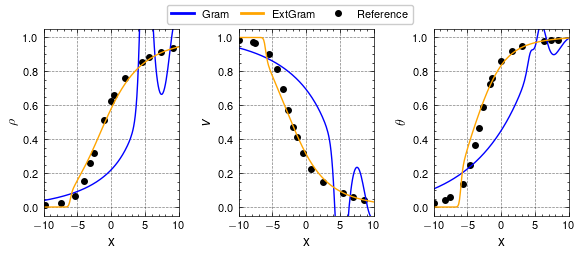

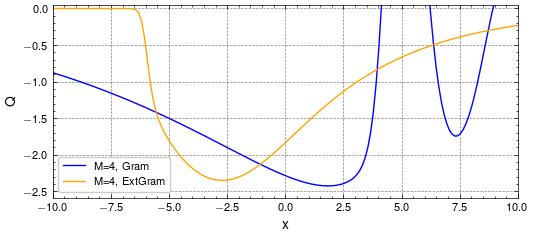

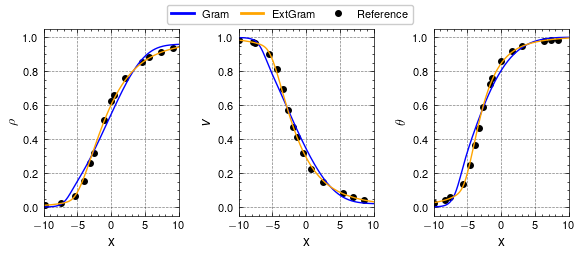

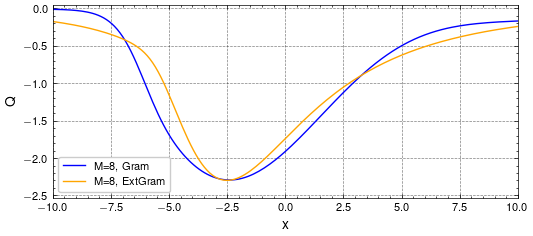

In [33]:
for i, Ma in enumerate(Mach):
    for M in Moments:
        fig, axs = plt.subplots(1, 3)
        fig_prim, ax_prim = plt.subplots()
        ax_prim.set_xlim(-10, 10)
        for j, closure in enumerate(closure_vec):
            file = filename_moments(M, closure, rho_L, rho_R(Ma), v_L(Ma), v_R(Ma), theta_L, theta_R(Ma))
            x, u, _ = sol_final(file)
            rho = u[:, 0]
            v = u[:, 1] / rho
            p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
            theta = p / rho

            axs[0].plot(x, (rho - rho_L) / (rho_R(Ma) - rho_L), color=colors[j])
            axs[1].plot(x, (v - v_R(Ma)) / (v_L(Ma) - v_R(Ma)), color=colors[j])
            axs[2].plot(x, (theta - theta_L) / (theta_R(Ma) - theta_L), color=colors[j])

            file_prim = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R(Ma)}_v_L{v_L(Ma)}_v_R{v_R(Ma)}_theta_L{theta_L}_theta_R{theta_R(Ma)}_base_tree_level{base_tree_level}_polydeg{polydeg}_prim.tsv"
            x, w, _ = sol_final(file_prim)
            q = w[:, 3]
            ax_prim.plot(x, q, color=colors[j], label=f'M={M}, {closure}')
            if closure == "ExtGram":
                ax_prim.set_ylim(np.min(q)*1.1, np.max(q)*1.1)
            ax_prim.legend()
            ax_prim.set_xlabel('x')
            ax_prim.set_ylabel('Q')
        
        # Reference solution
        ref = ref_data[i]
        scatter_every = 10
        axs[0].scatter(ref['rho'][0][::scatter_every], ref['rho'][1][::scatter_every], color='black')
        axs[1].scatter(ref['v'][0][::scatter_every], ref['v'][1][::scatter_every], color='black')
        axs[2].scatter(ref['theta'][0][::scatter_every], ref['theta'][1][::scatter_every], color='black')

        [ax.set_xlim(-10, 10) for ax in axs]
        [ax.set_ylim(-0.05, 1.05) for ax in axs]
        [ax.set_xlabel('x') for ax in axs]
        [ax.set_ylabel(label) for ax, label in zip(axs, ['$\\rho$', '$v$', '$\\theta$'])]
        # [axs[i].set_title(f'{labels[i]})', loc='left') for i in range(3)]

        closure_elements = [Line2D([0], [0], color=colors[i], lw=2, label=closure_vec[i]) for i in range(len(closure_vec))] + [Line2D([0], [0], color='black', marker='o', lw=0, label='Reference')]
        leg = fig.legend(
            handles=closure_elements, 
            loc='upper center', 
            bbox_to_anchor=(0.5, 1.06), 
            ncol=4, 
            # frameon=True,
            columnspacing=1.0 # Adjust spacing between columns
        )

        fig.tight_layout()
        fig.savefig(f'../out/Figures/ModelConvergence/ShockStructure_Ma{Ma}_M{M}.pdf', bbox_inches='tight')
        fig.show()

In [34]:
# DVM
N = 200#! 800
c_l = -10.0
c_u = 10.0
base_tree_level_DVM = 8

/tmp/ipykernel_21642/1924319872.py:53: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


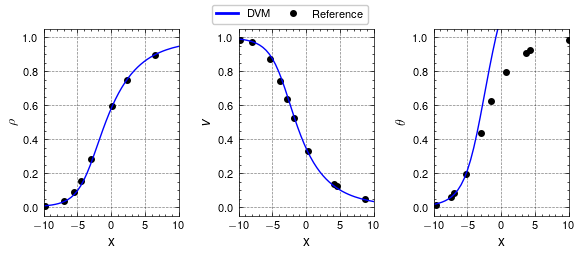

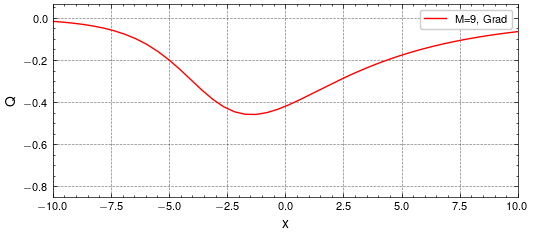

In [40]:
Mach = [1.4]
for i, Ma in enumerate(Mach):
    fig, axs = plt.subplots(1, 3)
    fig_prim, ax_prim = plt.subplots()
    ax_prim.set_xlim(-10, 10)
    
    data_bgk = pd.read_csv(f'../out/Riemann1D/BGK/bgk_solution_N{N}_c_l{c_l}_c_u{c_u}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R(Ma)}_v_L{v_L(Ma)}_v_R{v_R(Ma)}_theta_L{theta_L}_theta_R{theta_R(Ma)}_base_tree_level{base_tree_level_DVM}_polydeg{polydeg}_x_left{x_lower}_x_right{x_upper}_rho_v_p.csv')

    x_bgk = data_bgk['x'].to_numpy()
    rho_bgk = data_bgk['rho'].to_numpy()
    v_bgk = data_bgk['v'].to_numpy()
    p_bgk = data_bgk['p'].to_numpy()
    theta_bgk = p_bgk / rho_bgk
    q_bgk = data_bgk['q'].to_numpy()

    axs[0].plot(x_bgk, (rho_bgk - rho_L) / (rho_R(Ma) - rho_L), color=colors[0])
    axs[1].plot(x_bgk, (v_bgk - v_R(Ma)) / (v_L(Ma) - v_R(Ma)), color=colors[0])
    axs[2].plot(x_bgk, (p_bgk - theta_L) / (theta_R(Ma) - theta_L), color=colors[0])

    # Reference solution
    ref = ref_data[i]
    scatter_every = 10
    axs[0].scatter(ref['rho'][0][::scatter_every], ref['rho'][1][::scatter_every], color='black')
    axs[1].scatter(ref['v'][0][::scatter_every], ref['v'][1][::scatter_every], color='black')
    axs[2].scatter(ref['theta'][0][::scatter_every], ref['theta'][1][::scatter_every], color='black')

    ax_prim.plot(x_bgk, q_bgk, color=colors[j], label=f'M={M}, {closure}')
    ax_prim.set_ylim(np.min(q)*1.1, np.max(q)*1.1)
    ax_prim.legend()
    ax_prim.set_xlabel('x')
    ax_prim.set_ylabel('Q')

    [ax.set_xlim(-10, 10) for ax in axs]
    [ax.set_ylim(-0.05, 1.05) for ax in axs]
    [ax.set_xlabel('x') for ax in axs]
    [ax.set_ylabel(label) for ax, label in zip(axs, ['$\\rho$', '$v$', '$\\theta$'])]

    closure_elements = [
        Line2D([0], [0], color=colors[0], lw=2, label='DVM'),
        Line2D([0], [0], color='black', marker='o', lw=0, label='Reference')
    ]
    leg = fig.legend(
        handles=closure_elements, 
        loc='upper center', 
        bbox_to_anchor=(0.5, 1.06), 
        ncol=4, 
        # frameon=True,
        columnspacing=1.0 # Adjust spacing between columns
    )

    fig.tight_layout()
    # fig.savefig(f'../out/Figures/ModelConvergence/RankineHugoniot_Ma{Ma}_M{M}.pdf', bbox_inches='tight')
    fig.show()

### Problems of Grad

In [36]:
Moments = [4, 6, 8, 9]
closure = "Grad"
Kn = 1.0
source = "relaxation_source"
T_end = 25.0
base_tree_level = 10
polydeg = 1

# Initial condition parameters for the RH problem
Mach = np.array([1.4])#, 2.0])

rho_L = 1.0
rho_R = lambda Ma: (2*Ma**2) / (Ma**2 + 1)
v_L = lambda Ma: np.sqrt(3) * Ma
v_R = lambda Ma: np.sqrt(3) / 2 * (Ma**2 + 1) / Ma
theta_L = 1.0
theta_R = lambda Ma: (3*Ma**2 - 1) * (Ma**2 + 1) / (4 * Ma**2)

x_lower = -20.0
x_upper = 100.0

/tmp/ipykernel_21642/125128210.py:50: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


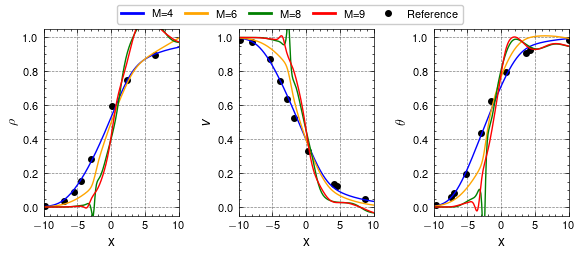

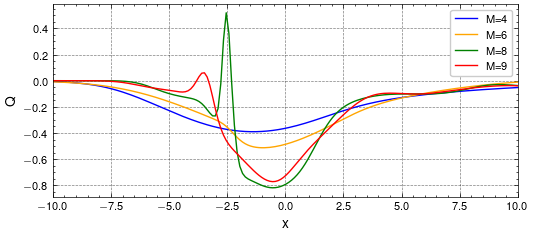

In [37]:
for i, Ma in enumerate(Mach):
    fig, axs = plt.subplots(1, 3)
    fig_prim, ax_prim = plt.subplots()
    ax_prim.set_xlim(-10, 10)
    for j, M in enumerate(Moments):
            file = filename_moments(M, closure, rho_L, rho_R(Ma), v_L(Ma), v_R(Ma), theta_L, theta_R(Ma))
            x, u, _ = sol_final(file)
            rho = u[:, 0]
            v = u[:, 1] / rho
            p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
            theta = p / rho

            axs[0].plot(x, (rho - rho_L) / (rho_R(Ma) - rho_L), color=colors[j])
            axs[1].plot(x, (v - v_R(Ma)) / (v_L(Ma) - v_R(Ma)), color=colors[j])
            axs[2].plot(x, (theta - theta_L) / (theta_R(Ma) - theta_L), color=colors[j])

            file_prim = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R(Ma)}_v_L{v_L(Ma)}_v_R{v_R(Ma)}_theta_L{theta_L}_theta_R{theta_R(Ma)}_base_tree_level{base_tree_level}_polydeg{polydeg}_prim.tsv"
            x, w, _ = sol_final(file_prim)
            q = w[:, 3]
            ax_prim.plot(x, q, color=colors[j], label=f'M={M}')
            ax_prim.legend()
            ax_prim.set_xlabel('x')
            ax_prim.set_ylabel('Q')
        
    # Reference solution
    ref = ref_data[i]
    scatter_every = 10
    axs[0].scatter(ref['rho'][0][::scatter_every], ref['rho'][1][::scatter_every], color='black')
    axs[1].scatter(ref['v'][0][::scatter_every], ref['v'][1][::scatter_every], color='black')
    axs[2].scatter(ref['theta'][0][::scatter_every], ref['theta'][1][::scatter_every], color='black')

    [ax.set_xlim(-10, 10) for ax in axs]
    [ax.set_ylim(-0.05, 1.05) for ax in axs]
    [ax.set_xlabel('x') for ax in axs]
    [ax.set_ylabel(label) for ax, label in zip(axs, ['$\\rho$', '$v$', '$\\theta$'])]
    # [axs[i].set_title(f'{labels[i]})', loc='left') for i in range(3)]

    closure_elements = [Line2D([0], [0], color=colors[j], lw=2, label=f'M={M}') for j, M in enumerate(Moments)] + [Line2D([0], [0], color='black', marker='o', lw=0, label='Reference')]
    leg = fig.legend(
        handles=closure_elements, 
        loc='upper center', 
        bbox_to_anchor=(0.5, 1.06), 
        ncol=5, 
        # frameon=True,
        columnspacing=1.0 # Adjust spacing between columns
    )

    fig.tight_layout()
    fig.savefig(f'../out/Figures/ModelConvergence/ShockStructure_Ma{Ma}_M{M}_Grad.pdf', bbox_inches='tight')
    fig.show()